# Field Learning Sweep Analysis

Analyze results from `field_learning_sweep.py`:
- MLP (ReLU/Tanh/GELU) vs SIREN
- Learning rate, depth, width effects
- Different target fields (single/multi Gaussian, sharp)
- Gradient learning vs scalar field learning

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load sweep results
results_path = Path('../results/field_sweep/sweep_results.npz')
data = np.load(results_path, allow_pickle=True)
all_results = json.loads(str(data['results']))

# Filter out failed experiments
results = [r for r in all_results if 'error' not in r]
print(f'Loaded {len(results)} successful experiments out of {len(all_results)} total')

Loaded 288 successful experiments out of 288 total


In [11]:
# Build a flat DataFrame for easy analysis
rows = []
for r in results:
    c = r['config']
    rows.append({
        'field': c['field_name'],
        'target': c['target'],
        'arch': c['arch'],
        'lr': c['lr'],
        'n_layers': c['n_layers'],
        'hidden_size': c['hidden_size'],
        'omega': c.get('omega', None),
        'final_rel_error': r['final_rel_error'],
        'final_loss': r['final_loss'],
        'n_params': r['n_params'],
        'time_s': r['time_seconds'],
        'converged': r['converged'],
    })
df = pd.DataFrame(rows)
print(f'Shape: {df.shape}')
df.head()

Shape: (288, 12)


,field,target,arch,lr,n_layers,hidden_size,omega,final_rel_error,final_loss,n_params,time_s,converged
0,single_gaussian,gradient,relu,0.0001,5,128,30.0,0.039571,0.000101,50435,7.432059,True
1,single_gaussian,scalar,relu,0.0001,5,128,30.0,0.011975,0.000006,50177,7.389702,True
2,single_gaussian,gradient,relu,0.0005,5,128,30.0,0.036508,0.000078,50435,6.884893,True
3,single_gaussian,scalar,relu,0.0005,5,128,30.0,0.006524,0.000002,50177,4.433921,True
4,single_gaussian,gradient,relu,0.0010,5,128,30.0,0.037355,0.000083,50435,4.331321,True


## 1. Architecture comparison: MLP variants vs SIREN

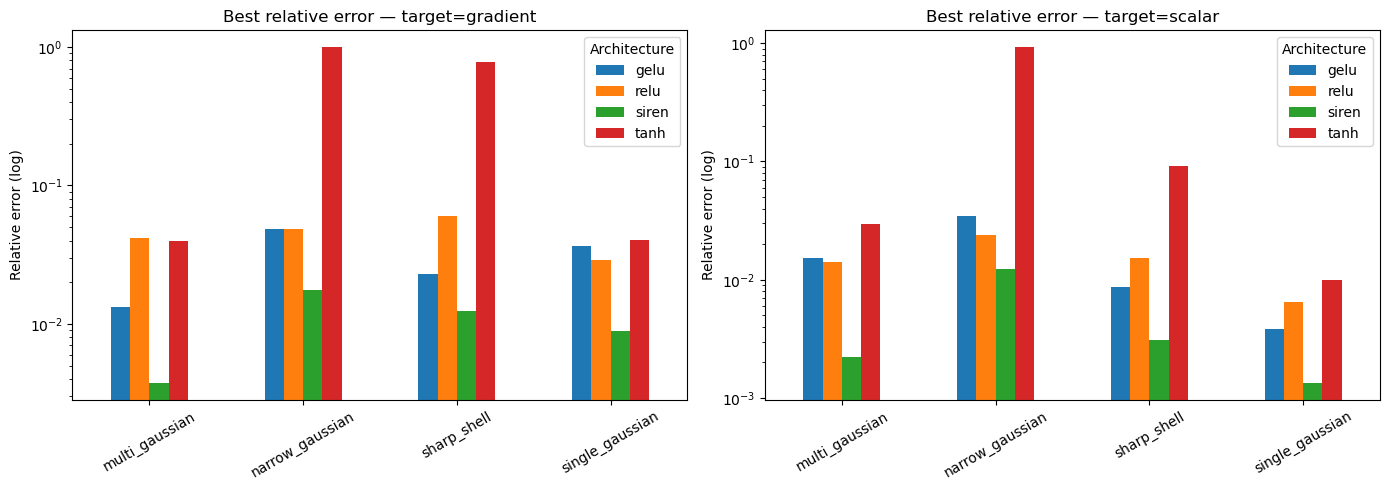

In [12]:
# Best relative error per (arch, field, target) — using default depth/width
default_mask = (df['n_layers'] == 5) & (df['hidden_size'] == 128)
best = df[default_mask].groupby(['field', 'target', 'arch'])['final_rel_error'].min().unstack('arch')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(['gradient', 'scalar']):
    sub = best.xs(target, level='target') if target in best.index.get_level_values('target') else None
    if sub is not None:
        sub.plot(kind='bar', ax=axes[i], logy=True)
        axes[i].set_title(f'Best relative error — target={target}')
        axes[i].set_ylabel('Relative error (log)')
        axes[i].set_xlabel('')
        axes[i].legend(title='Architecture')
        axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 2. Learning rate sensitivity

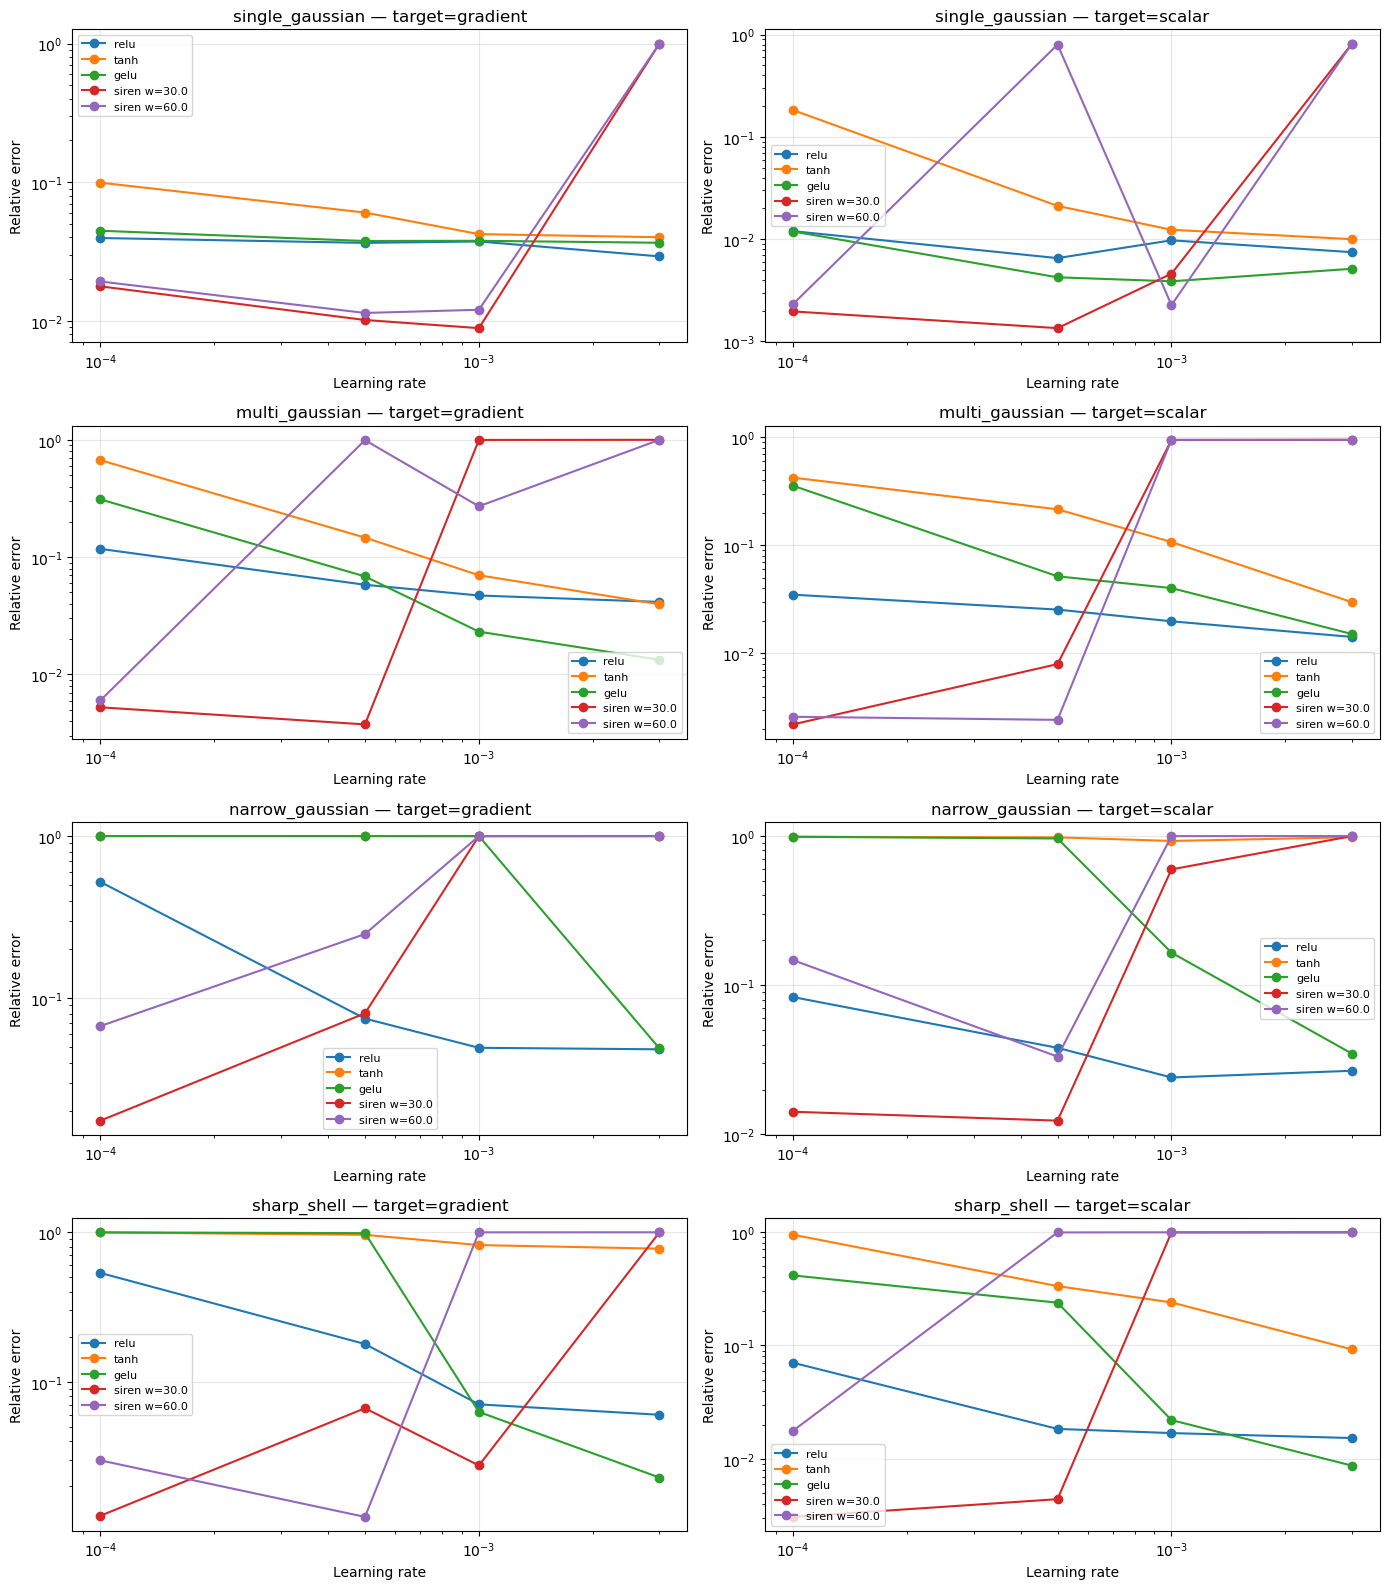

In [13]:
fields = df['field'].unique()
archs = df['arch'].unique()

fig, axes = plt.subplots(len(fields), 2, figsize=(14, 4 * len(fields)), squeeze=False)

for row, field_name in enumerate(fields):
    for col, target in enumerate(['gradient', 'scalar']):
        ax = axes[row, col]
        sub = df[(df['field'] == field_name) & (df['target'] == target) &
                 (df['n_layers'] == 5) & (df['hidden_size'] == 128)]
        if sub.empty:
            ax.set_visible(False)
            continue
        for arch in archs:
            s = sub[sub['arch'] == arch].sort_values('lr')
            if not s.empty:
                label = arch
                if arch == 'siren':
                    for omega, sg in s.groupby('omega'):
                        ax.plot(sg['lr'], sg['final_rel_error'], 'o-', label=f'siren w={omega}')
                else:
                    ax.plot(s['lr'], s['final_rel_error'], 'o-', label=arch)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Learning rate')
        ax.set_ylabel('Relative error')
        ax.set_title(f'{field_name} — target={target}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Depth and width effects

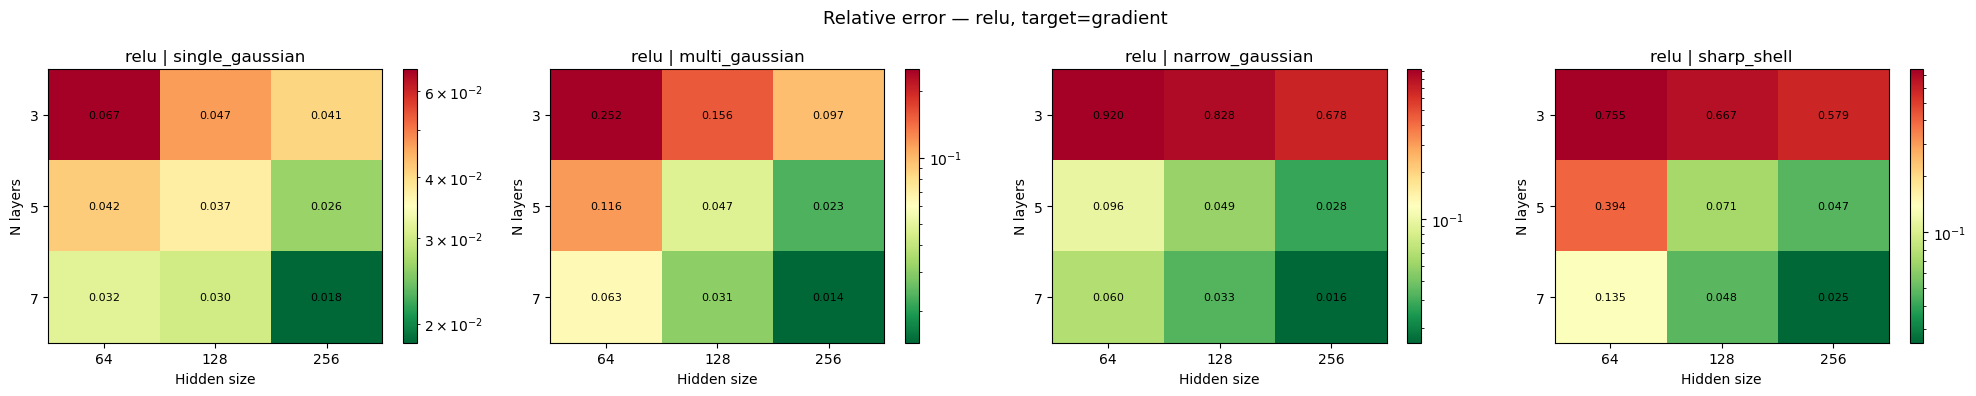

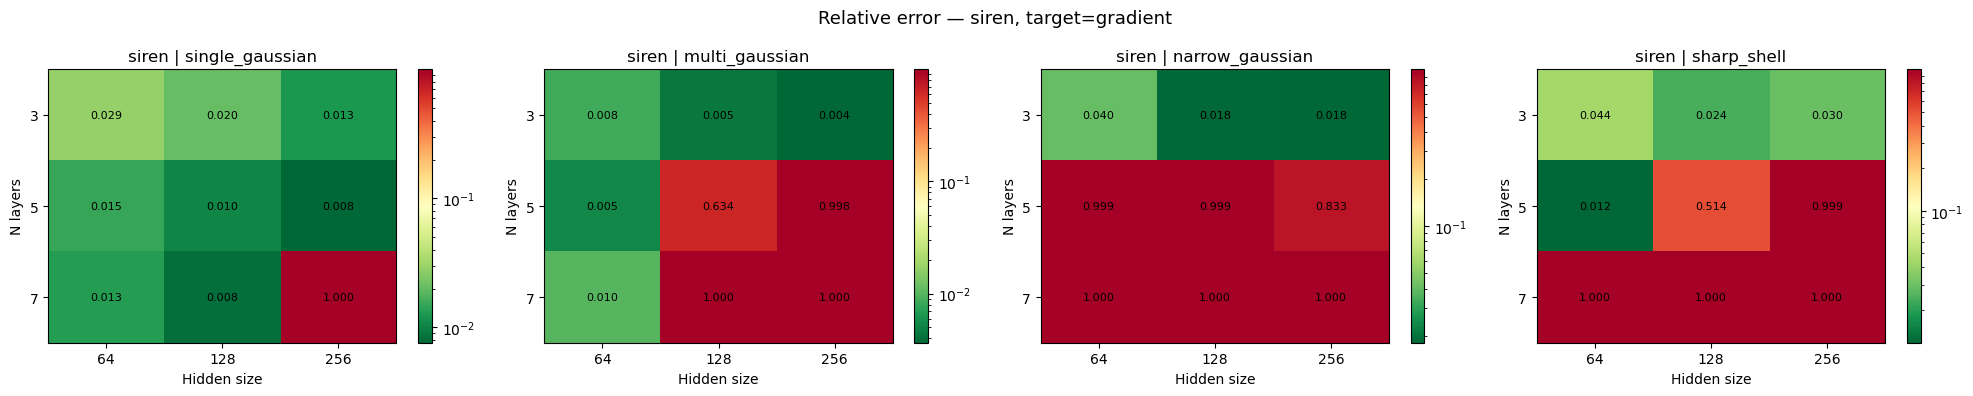

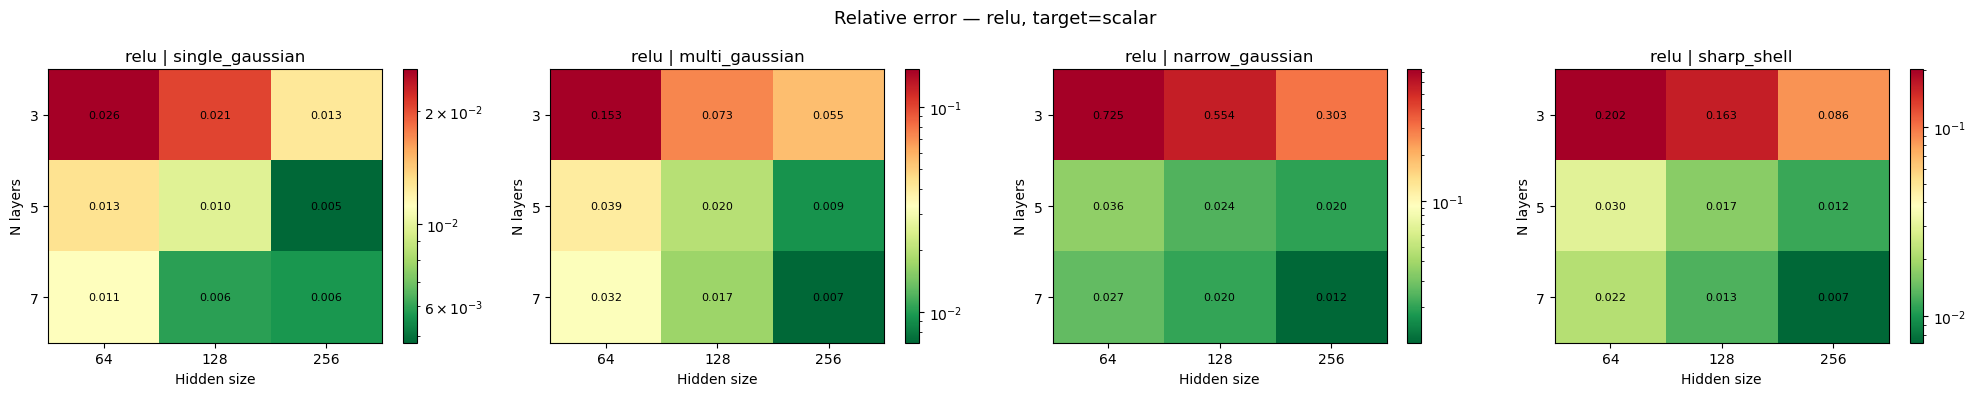

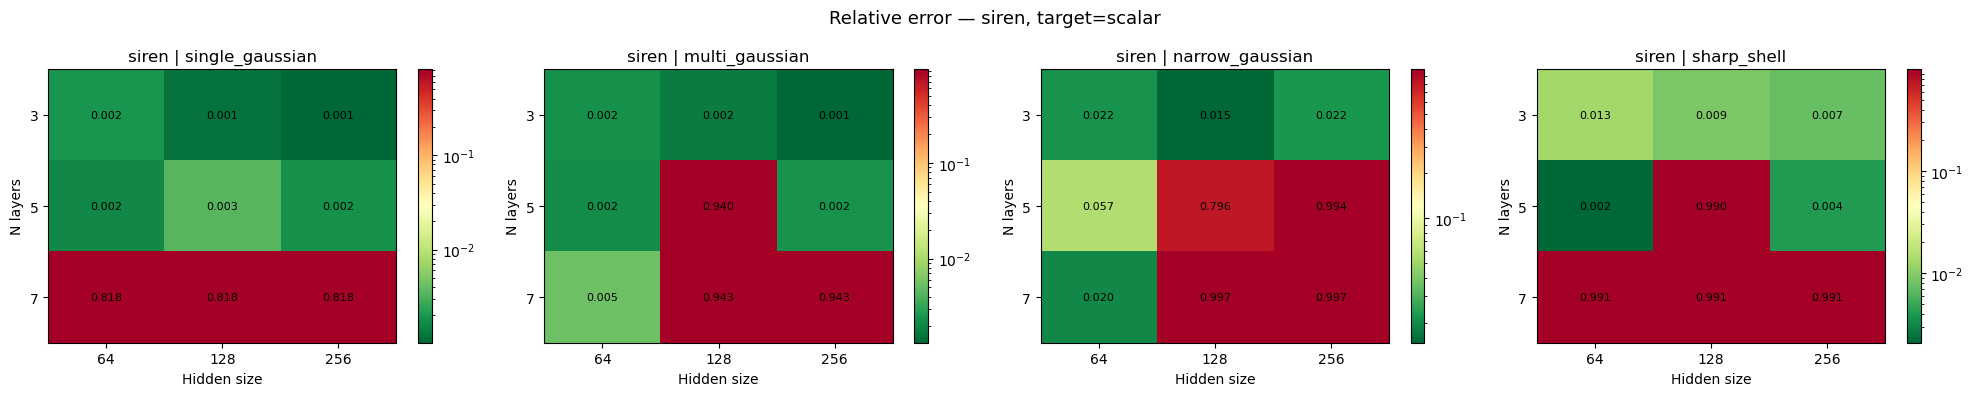

In [14]:
# Heatmap: n_layers x hidden_size for each (arch, field)
for target in ['gradient', 'scalar']:
    for arch in ['relu', 'siren']:
        sub = df[(df['arch'] == arch) & (df['lr'] == 1e-3) & (df['target'] == target)]
        if sub.empty:
            continue
        fields_here = sub['field'].unique()
        fig, axes = plt.subplots(1, len(fields_here), figsize=(5 * len(fields_here), 4))
        if len(fields_here) == 1:
            axes = [axes]
        for ax, fn in zip(axes, fields_here):
            pivot = sub[sub['field'] == fn].pivot_table(
                values='final_rel_error', index='n_layers', columns='hidden_size')
            im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                           norm=plt.matplotlib.colors.LogNorm())
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel('Hidden size')
            ax.set_ylabel('N layers')
            ax.set_title(f'{arch} | {fn}')
            # annotate cells
            for yi in range(len(pivot.index)):
                for xi in range(len(pivot.columns)):
                    val = pivot.values[yi, xi]
                    if not np.isnan(val):
                        ax.text(xi, yi, f'{val:.3f}', ha='center', va='center', fontsize=8)
            plt.colorbar(im, ax=ax)
        fig.suptitle(f'Relative error — {arch}, target={target}', fontsize=13)
        plt.tight_layout()
        plt.show()

## 4. Gradient vs scalar field learning

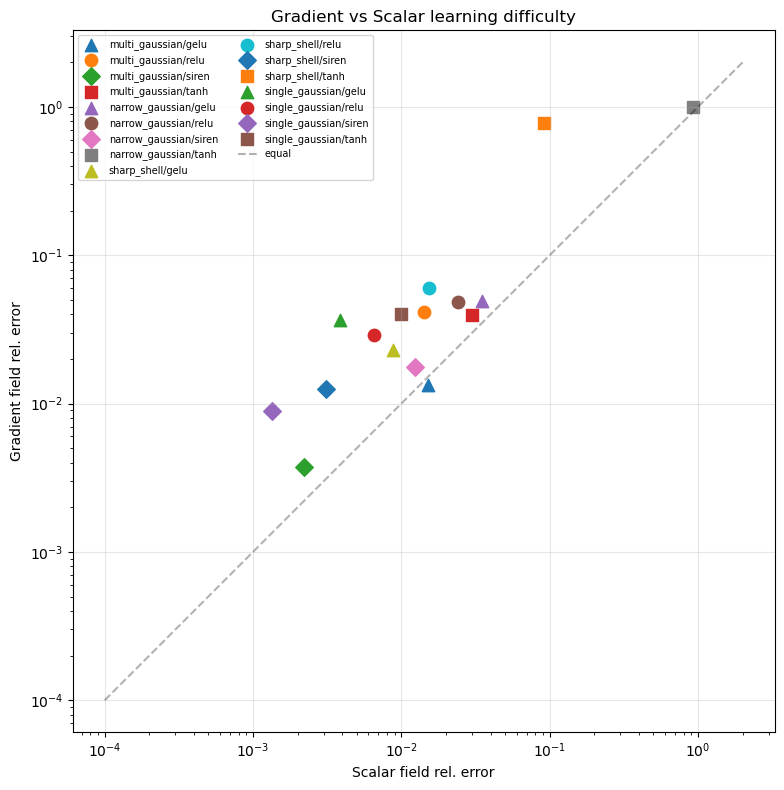

In [15]:
# Compare gradient vs scalar learning for each arch/field combo
compare = df[default_mask].groupby(['field', 'arch', 'target'])['final_rel_error'].min().unstack('target')
compare = compare.dropna()

fig, ax = plt.subplots(figsize=(8, 8))
for (field_name, arch), row in compare.iterrows():
    marker = {'relu': 'o', 'tanh': 's', 'gelu': '^', 'siren': 'D'}.get(arch, 'x')
    ax.scatter(row['scalar'], row['gradient'], marker=marker, s=80, label=f'{field_name}/{arch}')

lims = [1e-4, 2]
ax.plot(lims, lims, 'k--', alpha=0.3, label='equal')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Scalar field rel. error')
ax.set_ylabel('Gradient field rel. error')
ax.set_title('Gradient vs Scalar learning difficulty')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. Convergence curves — selected experiments

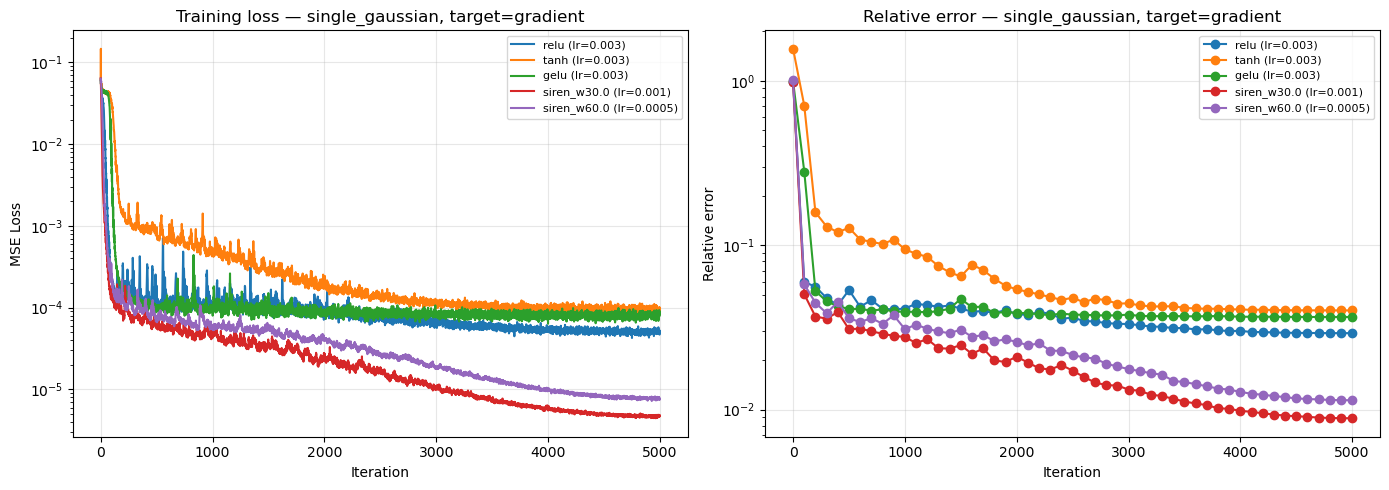

In [16]:
# Show loss and relative error curves for best config per (arch, field)
field_name = 'single_gaussian'  # change to explore others
target = 'gradient'

sub_results = [r for r in results
               if r['config']['field_name'] == field_name
               and r['config']['target'] == target
               and r['config']['n_layers'] == 5
               and r['config']['hidden_size'] == 128]

# pick best LR per arch
best_per_arch = {}
for r in sub_results:
    arch = r['config']['arch']
    key = arch if arch != 'siren' else f"siren_w{r['config']['omega']}"
    if key not in best_per_arch or r['final_rel_error'] < best_per_arch[key]['final_rel_error']:
        best_per_arch[key] = r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in best_per_arch.items():
    lr = r['config']['lr']
    axes[0].semilogy(r['losses'], label=f"{name} (lr={lr})")
    iters, rels = zip(*r['rel_errors'])
    axes[1].semilogy(iters, rels, 'o-', label=f"{name} (lr={lr})")

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title(f'Training loss — {field_name}, target={target}')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Relative error')
axes[1].set_title(f'Relative error — {field_name}, target={target}')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary table

In [17]:
# Best result per (field, target, arch)
summary = df.loc[df.groupby(['field', 'target', 'arch'])['final_rel_error'].idxmin()]
summary = summary[['field', 'target', 'arch', 'lr', 'n_layers', 'hidden_size',
                    'final_rel_error', 'n_params', 'time_s', 'converged']]
summary = summary.sort_values(['field', 'target', 'final_rel_error'])
summary.reset_index(drop=True, inplace=True)

print(f"Converged: {summary['converged'].sum()} / {len(summary)}")
summary

Converged: 28 / 32


,field,target,arch,lr,n_layers,hidden_size,final_rel_error,n_params,time_s,converged
0,multi_gaussian,gradient,siren,0.0010,3,256,0.003653,67587,3.695956,True
1,multi_gaussian,gradient,gelu,0.0030,5,128,0.013335,50435,4.263889,True
2,multi_gaussian,gradient,relu,0.0010,7,256,0.014368,330755,7.077394,True
3,multi_gaussian,gradient,tanh,0.0030,5,128,0.039654,50435,4.341689,True
4,multi_gaussian,scalar,siren,0.0010,3,256,0.001326,67073,3.876885,True
5,multi_gaussian,scalar,relu,0.0010,7,256,0.007060,330241,7.021002,True
6,multi_gaussian,scalar,gelu,0.0030,5,128,0.015126,50177,4.520371,True
7,multi_gaussian,scalar,tanh,0.0030,5,128,0.029767,50177,4.345120,True
8,narrow_gaussian,gradient,relu,0.0010,7,256,0.015979,330755,7.027549,True
9,narrow_gaussian,gradient,siren,0.0001,5,128,0.017506,50435,4.828136,True


## 7. Failure analysis — when does it fail?

In [18]:
# Show experiments that did NOT converge
failed = df[~df['converged']].copy()
failed = failed.sort_values('final_rel_error', ascending=False)

print(f"{len(failed)} experiments did not converge (rel_error >= 0.05)\n")

# Failure patterns
print("Failure rate by architecture:")
print(df.groupby('arch')['converged'].apply(lambda x: f"{(~x).sum()}/{len(x)}"))
print()
print("Failure rate by field:")
print(df.groupby('field')['converged'].apply(lambda x: f"{(~x).sum()}/{len(x)}"))
print()
print("Failure rate by target:")
print(df.groupby('target')['converged'].apply(lambda x: f"{(~x).sum()}/{len(x)}"))

135 experiments did not converge (rel_error >= 0.05)

Failure rate by architecture:
arch
gelu      15/32
relu      35/96
siren    60/128
tanh      25/32
Name: converged, dtype: object

Failure rate by field:
field
multi_gaussian     34/72
narrow_gaussian    46/72
sharp_shell        42/72
single_gaussian    13/72
Name: converged, dtype: object

Failure rate by target:
target
gradient    76/144
scalar      59/144
Name: converged, dtype: object
